In [1]:
import pandas as pd
import zipfile
import os
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

print("All modules imported successfully!")

All modules imported successfully!


In [35]:
# loading the data we will only see the first 8 coluns
import zipfile
import pandas as pd

zip_path = r"C:\Users\Admin\Downloads\archive.zip"  # path to your ZIP file

with zipfile.ZipFile(zip_path) as z:
    with z.open("StudentPerformanceFactors.csv") as f:
        df = pd.read_csv(f)

# Show the first few rows
df.head(8)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66


In [36]:
# see column name and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [37]:
# viewing the first 5 columns
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [38]:
# viewing the last six collumns
df.tail(6)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6601,20,83,Medium,Low,No,6,51,Low,Yes,2,Medium,Medium,Public,Neutral,4,No,High School,Moderate,Female,65
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [39]:
# describing the data
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [40]:
#checking missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [41]:
#count unique values
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

Parental_Involvement 3
Access_to_Resources 3
Extracurricular_Activities 2
Motivation_Level 3
Internet_Access 2
Family_Income 3
Teacher_Quality 3
School_Type 2
Peer_Influence 3
Learning_Disabilities 2
Parental_Education_Level 3
Distance_from_Home 3
Gender 2


In [48]:

# Fill categorical columns with mode since none nothing displayed
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with mean
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].mean())

In [47]:
# remove dublicates and since there is none nothing will be displayed
df.drop_duplicates(inplace=True)

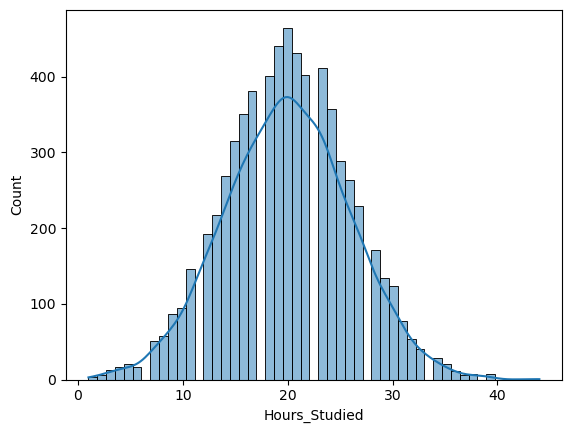

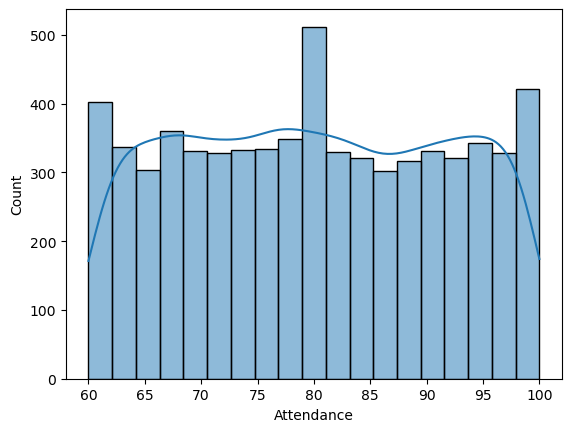

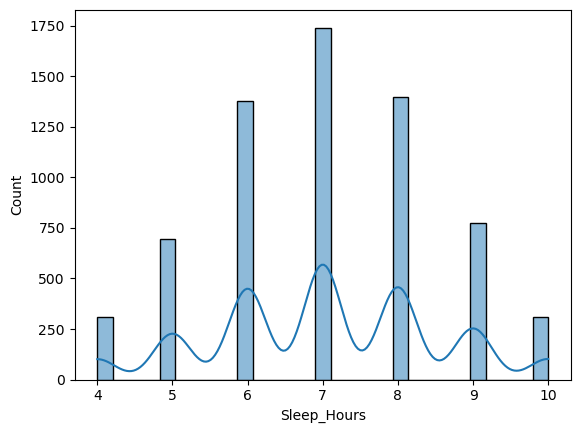

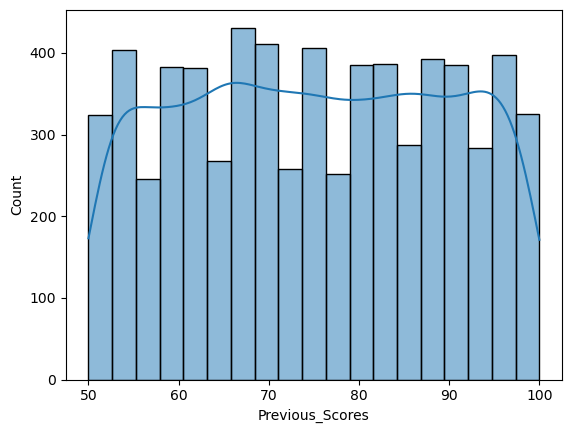

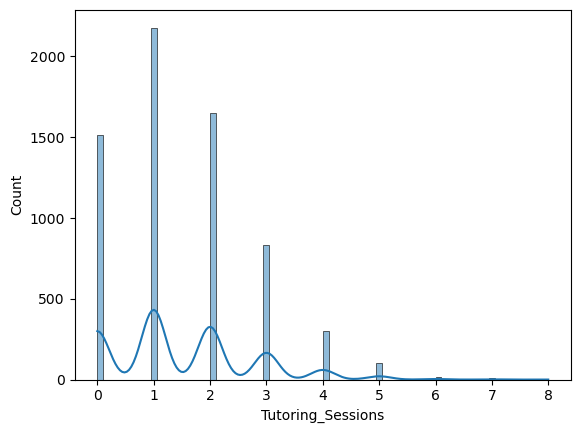

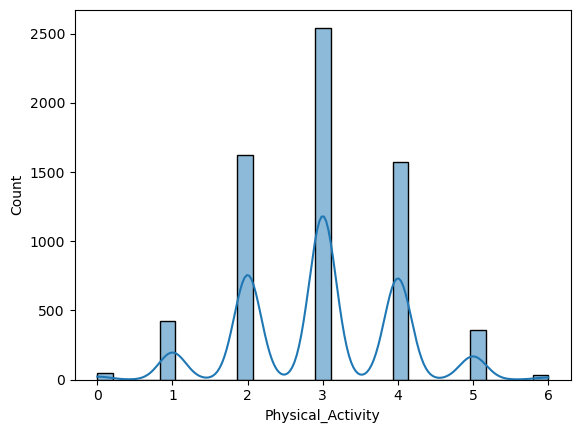

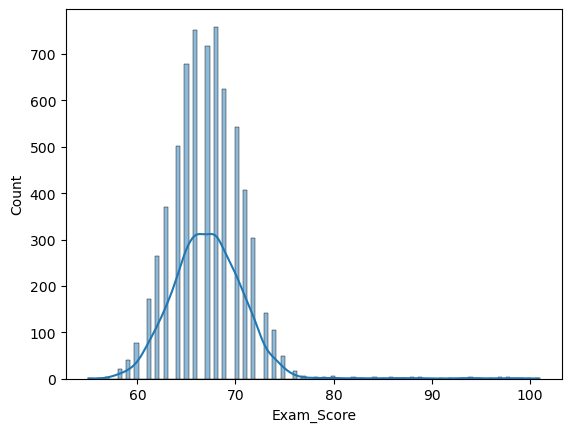

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include='number').columns:
    sns.histplot(df[col], kde=True)
    plt.show()

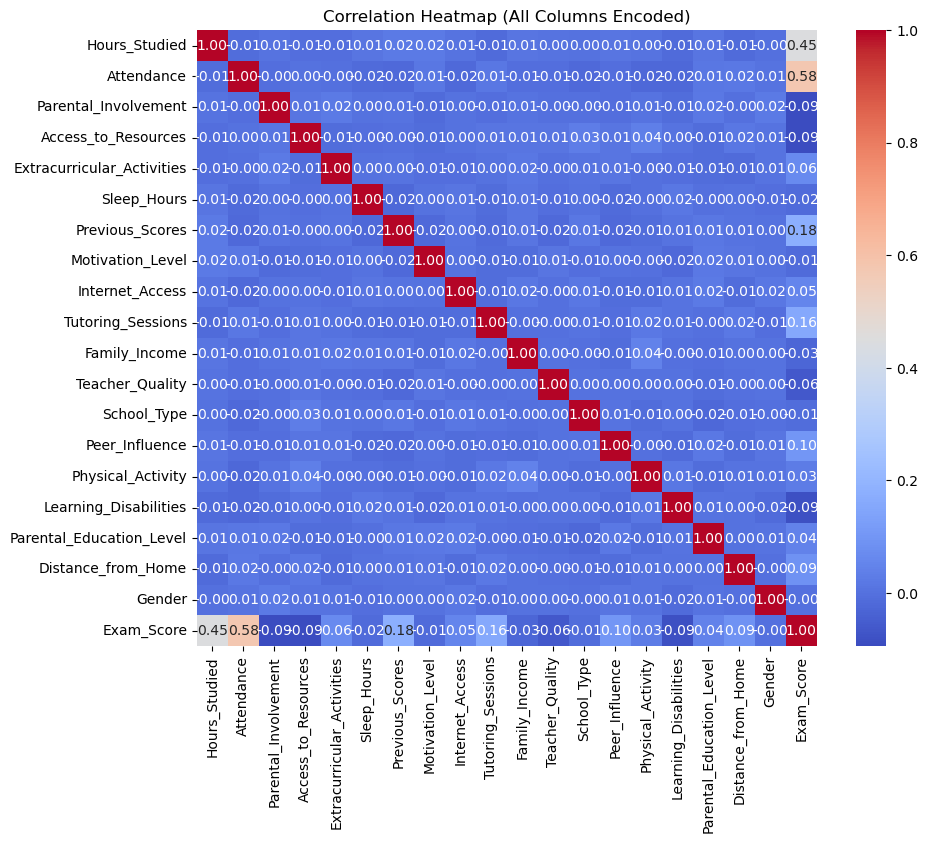

In [51]:
# Convert categorical columns to numeric codes
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (All Columns Encoded)")
plt.show()

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1️⃣ Strip any extra spaces in column names
df.columns = df.columns.str.strip()

# 2️⃣ Automatically detect the target as the last column
target_col = df.columns[-1]

# 3️⃣ Encode the target if it's categorical
if df[target_col].dtype == 'object' or str(df[target_col].dtype).startswith('category'):
    df[target_col] = df[target_col].astype('category').cat.codes

# 4️⃣ Separate target
y = df[target_col]

# 5️⃣ Encode categorical features (exclude target)
X = pd.get_dummies(df.drop(columns=target_col), drop_first=True)

# 6️⃣ Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7️⃣ Optional: check shapes
print("Target column detected:", target_col)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Target column detected: Exam_Score
X_train: (5285, 27)
X_test : (1322, 27)
y_train: (5285,)
y_test : (1322,)


In [56]:
# training the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Create the model
model = LogisticRegression(max_iter=1000)

# 2️⃣ Train the model
model.fit(X_train, y_train)

# 3️⃣ Make predictions
y_pred = model.predict(X_test)

# 4️⃣ Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.1913767019667171

Classification Report:
               precision    recall  f1-score   support

          55       0.00      0.00      0.00         1
          57       0.00      0.00      0.00         2
          58       0.00      0.00      0.00         3
          59       0.00      0.00      0.00         5
          60       0.33      0.08      0.12        13
          61       0.32      0.31      0.31        26
          62       0.10      0.07      0.08        54
          63       0.22      0.10      0.14        77
          64       0.18      0.16      0.17        94
          65       0.24      0.32      0.27       148
          66       0.24      0.33      0.28       144
          67       0.22      0.18      0.20       142
          68       0.18      0.27      0.21       147
          69       0.17      0.19      0.18       118
          70       0.19      0.18      0.19       116
          71       0.11      0.07      0.09        84
          72       0.11    

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


✅ Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
Accuracy: 0.2723146747352496

Classification Report:
               precision    recall  f1-score   support

          55       0.00      0.00      0.00         1
          57       0.00      0.00      0.00         2
          58       0.00      0.00      0.00         3
          59       0.00      0.00      0.00         5
          60       0.00      0.00      0.00        13
          61       0.30      0.31      0.30        26
          62       0.23      0.11      0.15        54
          63       0.30      0.22      0.25        77
          64       0.25      0.22      0.24        94
          65       0.30      0.37      0.33       148
          66       0.28      0.38      0.32       144
          67       0.28      0.25      0.26       142
          68       0.27      0.39      0.32       147
          69       0.26      0.31      0.28       118
         

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


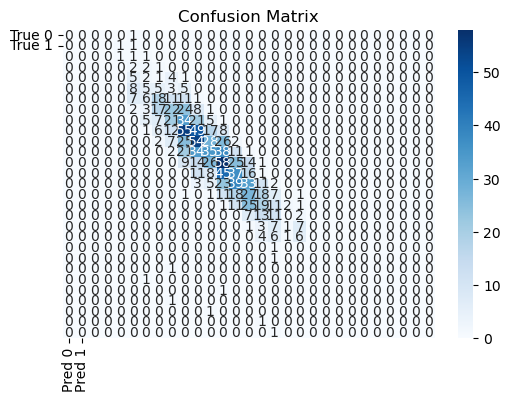

C:\Users\Admin\AppData\Local\Temp\ipykernel_5356\2859294160.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[sorted_idx], y=feature_names[sorted_idx], palette="viridis")


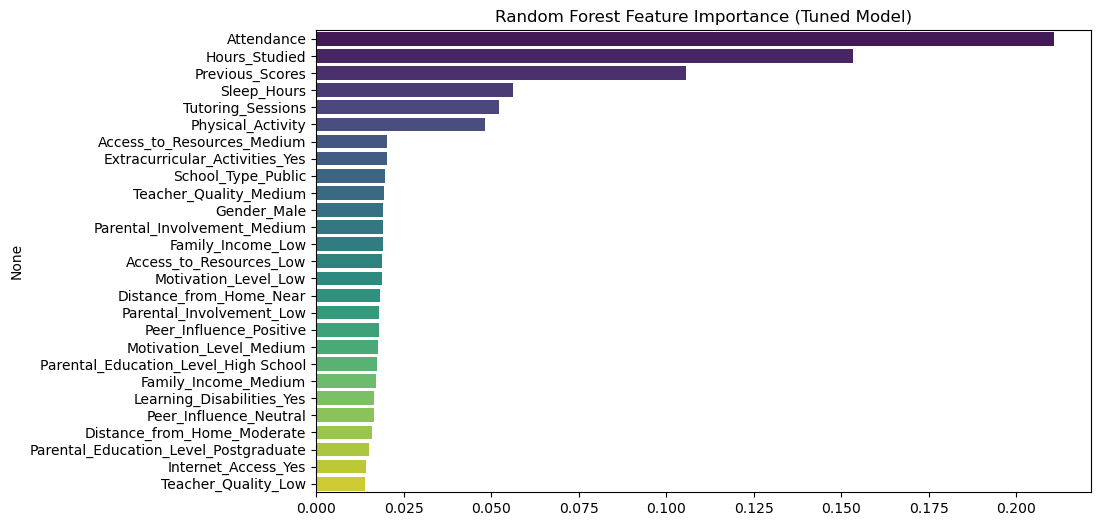

In [59]:
# training random forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Define the model
rf_model = RandomForestClassifier(random_state=42)

# 2️⃣ Define the hyperparameter grid (distributions for RandomizedSearch)
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 3️⃣ Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,            # try 20 random combinations
    cv=5,                 # 5-fold cross-validation
    verbose=1,
    n_jobs=-1,
    random_state=42,
    scoring='accuracy'
)

# 4️⃣ Train the model
random_search.fit(X_train, y_train)

# 5️⃣ Best model
best_rf = random_search.best_estimator_
print("✅ Best Parameters:", random_search.best_params_)

# 6️⃣ Make predictions
y_pred = best_rf.predict(X_test)

# 7️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8️⃣ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title("Confusion Matrix")
plt.show()

# 9️⃣ Feature importance
importances = best_rf.feature_importances_
feature_names = X_train.columns
sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[sorted_idx], y=feature_names[sorted_idx], palette="viridis")
plt.title("Random Forest Feature Importance (Tuned Model)")
plt.show()


In [60]:
import joblib

# =========================
# 4️⃣ Save the trained model
# =========================

# Save the best Random Forest model to a file
model_filename = "best_random_forest_model.pkl"
joblib.dump(best_rf, model_filename)
print(f"✅ Model saved as '{model_filename}'")

# =========================
# 5️⃣ Load the model later
# =========================

# Load the model from the file
loaded_model = joblib.load(model_filename)

# Use it to make predictions
y_pred_loaded = loaded_model.predict(X_test)
print("Accuracy with loaded model:", accuracy_score(y_test, y_pred_loaded))

✅ Model saved as 'best_random_forest_model.pkl'
Accuracy with loaded model: 0.2723146747352496
